# Non-new complex rules across stages — eligible FOVs


## Imports


In [1]:
import os
import sys
import warnings

from IPython.display import Markdown, display

warnings.filterwarnings("ignore")
sys.path[:0] = [os.path.abspath(".."), os.path.abspath("../..")]

import data_helper as dh
import vis_helper as vh
import complex_stages_helper as stage
import complex_stages_vis as vis


## Parameters


In [2]:
RULE_MAX_ITEMS = 3
KINDS = ["attracts", "avoids"]
MAX_FDR = 0.05
STRENGTH_METRIC = "Lift"

# The stage column is chosen per run, not per notebook:
#   SCORE_COLUMN="Pathological score" jupyter nbconvert --execute ...
SCORE_COLUMN = os.environ.get("SCORE_COLUMN", "Clinical score")
SCORE_TAG = "path" if SCORE_COLUMN.startswith("Patho") else "clin"
STAGES = ["Control", "Mild", "Severe"]
ORGANS = ["Colon", "Duodenum"]

USE_CELL_ELIGIBILITY = True
MIN_CELLS_PER_TYPE = 20
MIN_RULE_FOVS = 5
TOP_RULES = 12
DETAIL_RULES = 2

SCOPE = "elig"    # tags every figure this notebook saves


## Data loading


In [3]:
df_cells, df_fovs, df_biopsy = dh.load_spatial_data()
df_results = dh.load_results(
    rule_max_items=RULE_MAX_ITEMS,
    kind=None,
    max_fdr=1.0,
    informative_only=False,
)
all_rules = stage.prepare_rules(df_results, df_fovs)


Dropped 21 FOVs: Control_S


Loaded 598093 cells; FOVs: 267, biopsies: 73, patients: 71


Read results_CN_pairwise.csv + results_CN_complex.csv
Loaded 1190114 rules.


Kept 1190114 rules at FDR <= 1.0.


Kept 1172931 rules naming no Unidentified.


Kept 213816 rules (max_items=3, kind=None).


## Short analysis functions


In [4]:
def slug(text):
    """A short file-safe name for a rule."""
    text = str(text).lower().replace(" -> ", "_").replace(",", "").replace(" ", "_")
    return "".join(ch for ch in text if ch.isalnum() or ch == "_")[:60]


def figure_name(scope, kind, organ, panel, name=None):
    """One naming rule for every figure this notebook saves."""
    parts = [scope, SCORE_TAG, kind, organ.lower(), panel]
    if name is not None:
        parts.append(slug(name))
    return "_".join(parts) + ".png"


def strength_label(kind):
    return STRENGTH_METRIC


def scope_label(kind):
    denominator = (
        f"{MIN_CELLS_PER_TYPE}+ cells per rule cell type"
        if USE_CELL_ELIGIBILITY else "all FOVs"
    )
    return " · ".join([
        kind,
        "non-new complex rules",
        f"stage column: {SCORE_COLUMN}",
        f"FDR <= {MAX_FDR}",
        denominator,
        f"at least {MIN_RULE_FOVS} rule FOVs in one stage",
    ])


## Results


In [5]:
def show_kind(kind):
    display(Markdown(f"## {kind.title()}"))
    kind_rules = all_rules[all_rules["Kind"] == kind].copy()
    complex_rules = stage.select_complex_rules(
        kind_rules,
        max_fdr=MAX_FDR,
        new_only=False,
        min_strength=1.0,
        metric=STRENGTH_METRIC,
    )
    eligibility = stage.rule_eligibility(
        complex_rules, df_cells, MIN_CELLS_PER_TYPE
    )

    for organ in ORGANS:
        display(Markdown(f"### {organ}"))
        prevalence = stage.stage_prevalence(
            complex_rules,
            kind_rules,
            eligibility,
            df_fovs,
            organ,
            STAGES,
            SCORE_COLUMN,
            MAX_FDR,
            USE_CELL_ELIGIBILITY,
        )
        top, ranked_names = stage.rank_rules(
            prevalence, STAGES, MIN_RULE_FOVS, TOP_RULES
        )
        display(stage.result_table(top, new_only=False))
        vis.plot_prevalence_overview(
            top,
            STAGES,
            organ=organ,
            params=scope_label(kind),
            save=figure_name(SCOPE, kind, organ, "overview"),
        )

        opposed = stage.opposite_direction_rules(
            prevalence, STAGES, MIN_RULE_FOVS
        )
        display(stage.opposite_table(opposed))
        vis.plot_opposite_directions(
            opposed, STAGES, organ=organ, params=scope_label(kind),
            save=figure_name(SCOPE, kind, organ, "opposite"),
        )

        chosen = stage.detail_rules(
            complex_rules, ranked_names, DETAIL_RULES, new_only=False
        )
        chosen = list(dict.fromkeys(chosen + list(ranked_names[:DETAIL_RULES])))
        for name in chosen:
            rule_prevalence = top[top["name"].astype(str) == name].copy()
            availability = stage.availability_breakdown(
                [name], complex_rules, kind_rules, eligibility, df_fovs,
                organ, STAGES, SCORE_COLUMN, MAX_FDR,
            )
            vis.plot_availability_breakdown(
                availability, STAGES, [name], organ=organ,
                params=scope_label(kind),
                save=figure_name(SCOPE, kind, organ, "avail", name),
            )
            strengths = stage.patient_strengths(
                name,
                complex_rules,
                kind_rules,
                eligibility,
                df_fovs,
                organ,
                STAGES,
                SCORE_COLUMN,
                STRENGTH_METRIC,
                USE_CELL_ELIGIBILITY,
            )
            abundance = stage.cell_abundance(
                name,
                complex_rules,
                df_cells,
                eligibility,
                df_fovs,
                organ,
                STAGES,
                SCORE_COLUMN,
                USE_CELL_ELIGIBILITY,
            )
            vis.plot_prevalence_and_strength(
                rule_prevalence,
                strengths,
                STAGES,
                metric=strength_label(kind),
                organ=organ,
                params=scope_label(kind),
                new_only=False,
                abundance=abundance,
                save=figure_name(SCOPE, kind, organ, "rule", name),
            )
            examples = stage.fov_examples(
                name,
                complex_rules,
                kind_rules,
                eligibility,
                df_fovs,
                organ,
                STAGES,
                SCORE_COLUMN,
                STRENGTH_METRIC,
                USE_CELL_ELIGIBILITY,
                new_only=False,
            )
            vh.plot_stage_rule_fovs(
                examples,
                STAGES,
                df_cells,
                df_fovs,
                organ=organ,
                subtitle="Complex rule and strongest simpler rule",
                params=scope_label(kind),
                cell_size=11,
                save=figure_name(SCOPE, kind, organ, "fovs", name),
            )


## Attractions


## Attracts

### Colon

,name,stage,complex prevalence,simpler prevalence
393,"Plasma -> CD4T, Epithelial",Control,5 / 25 (20%),15 / 25 (60%)
394,"Plasma -> CD4T, Epithelial",Mild,2 / 10 (20%),2 / 10 (20%)
395,"Plasma -> CD4T, Epithelial",Severe,0 / 17 (0%),3 / 17 (18%)
798,"Plasma -> CD8T, Macrophage",Control,5 / 25 (20%),13 / 25 (52%)
799,"Plasma -> CD8T, Macrophage",Mild,0 / 8 (0%),2 / 8 (25%)
800,"Plasma -> CD8T, Macrophage",Severe,0 / 18 (0%),4 / 18 (22%)


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\elig_path_attracts_colon_overview.png


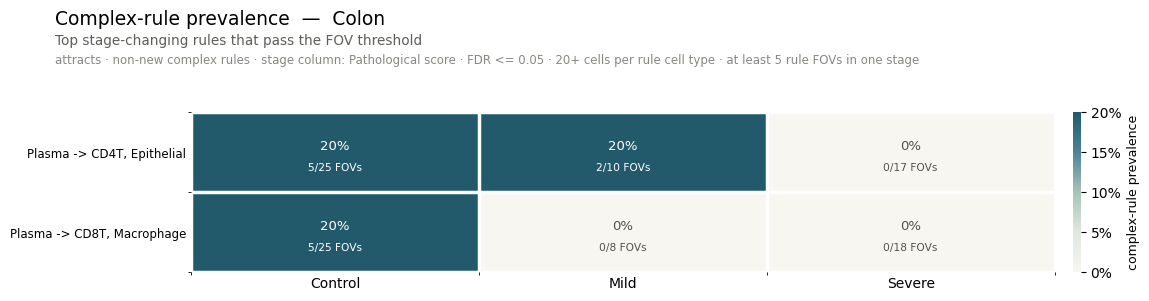

,note
0,No rule moves both ways by the required margin.


No opposite-direction rules to plot.


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\elig_path_attracts_colon_avail_plasma_cd4t_epithelial.png


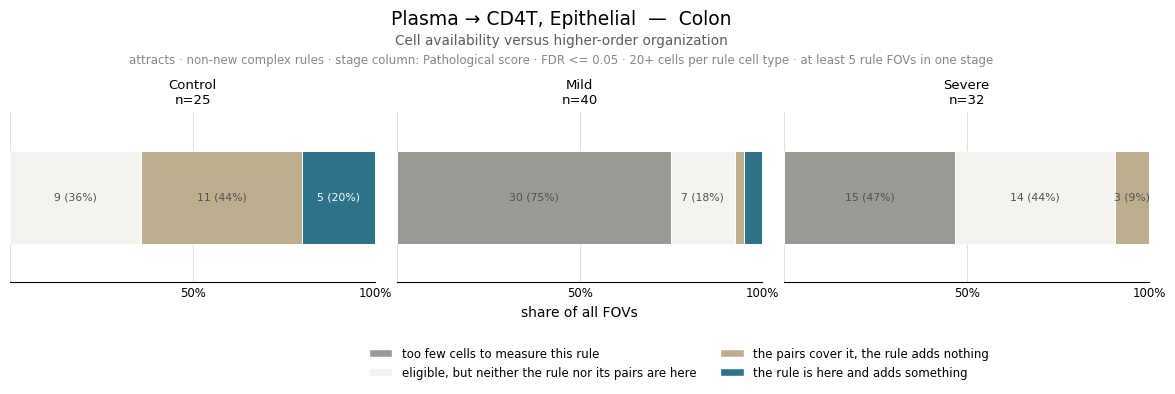

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\elig_path_attracts_colon_rule_plasma_cd4t_epithelial.png


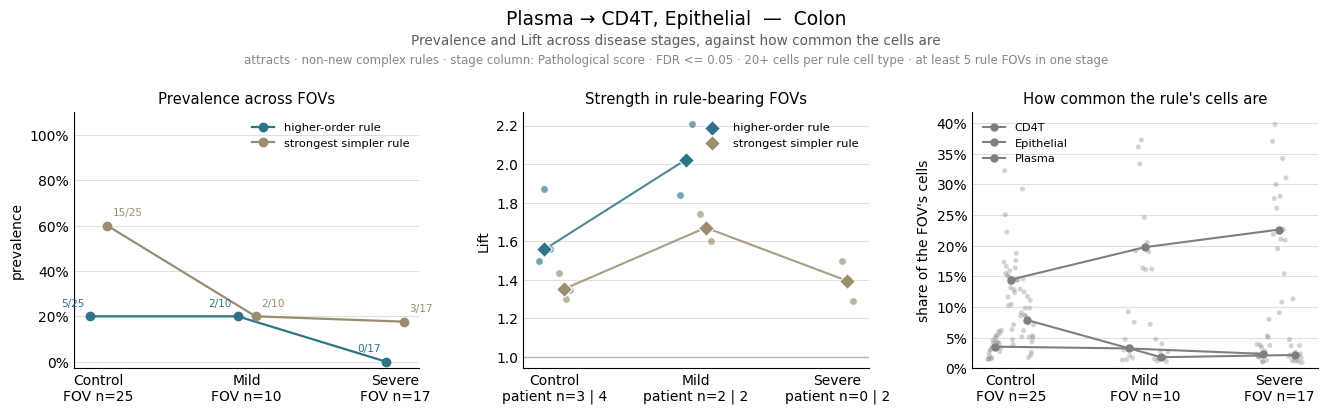

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\elig_path_attracts_colon_fovs_plasma_cd4t_epithelial.png


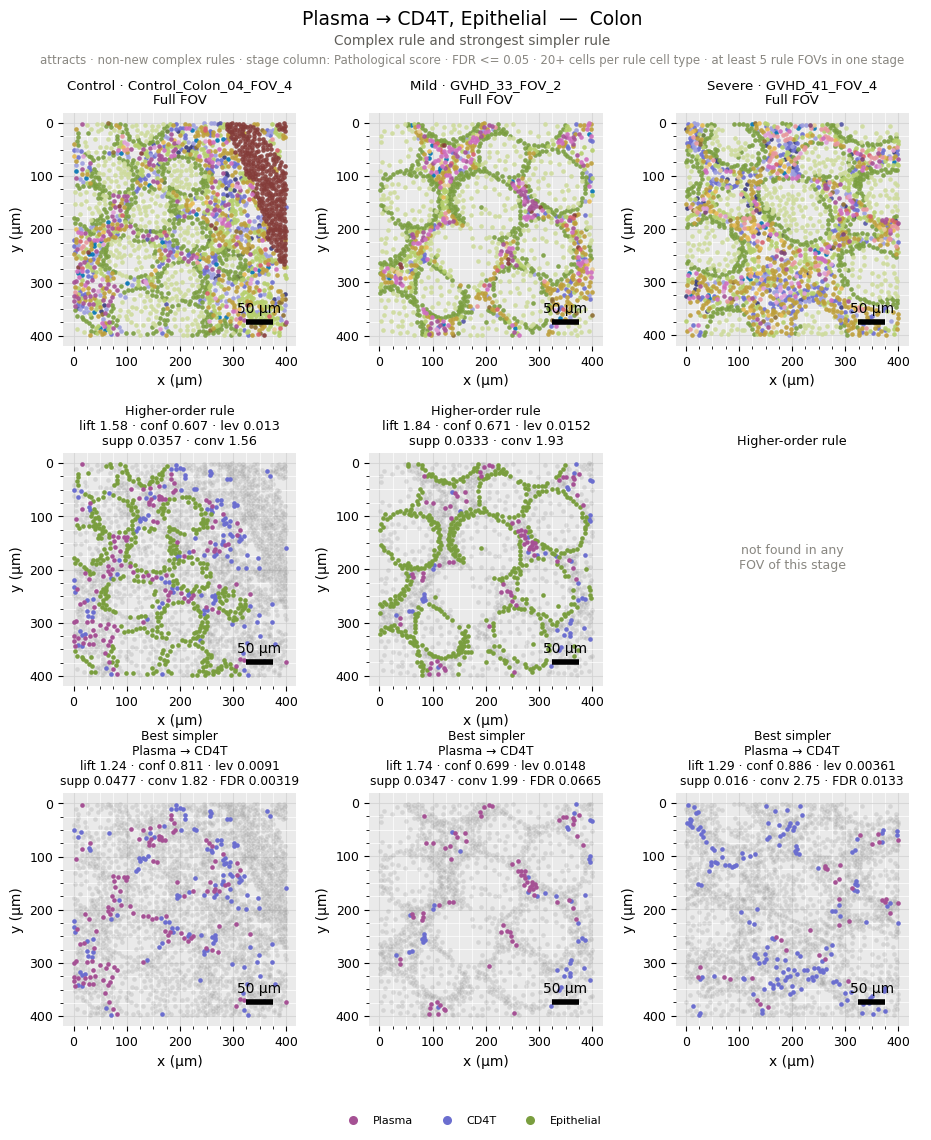

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\elig_path_attracts_colon_avail_plasma_cd8t_macrophage.png


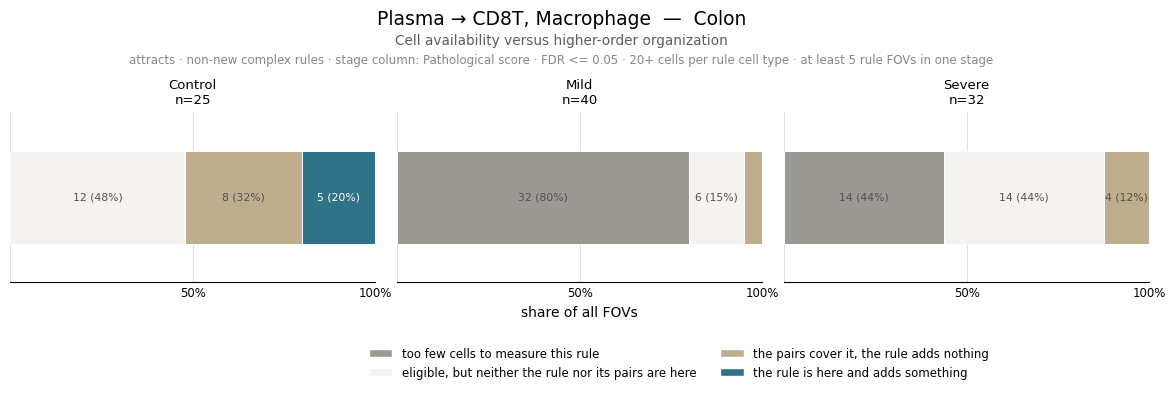

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\elig_path_attracts_colon_rule_plasma_cd8t_macrophage.png


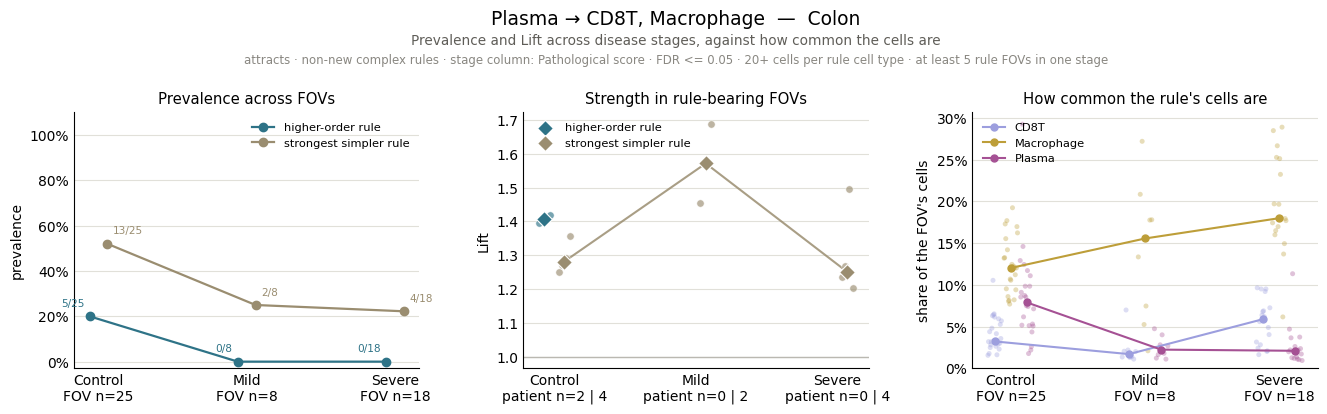

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\elig_path_attracts_colon_fovs_plasma_cd8t_macrophage.png


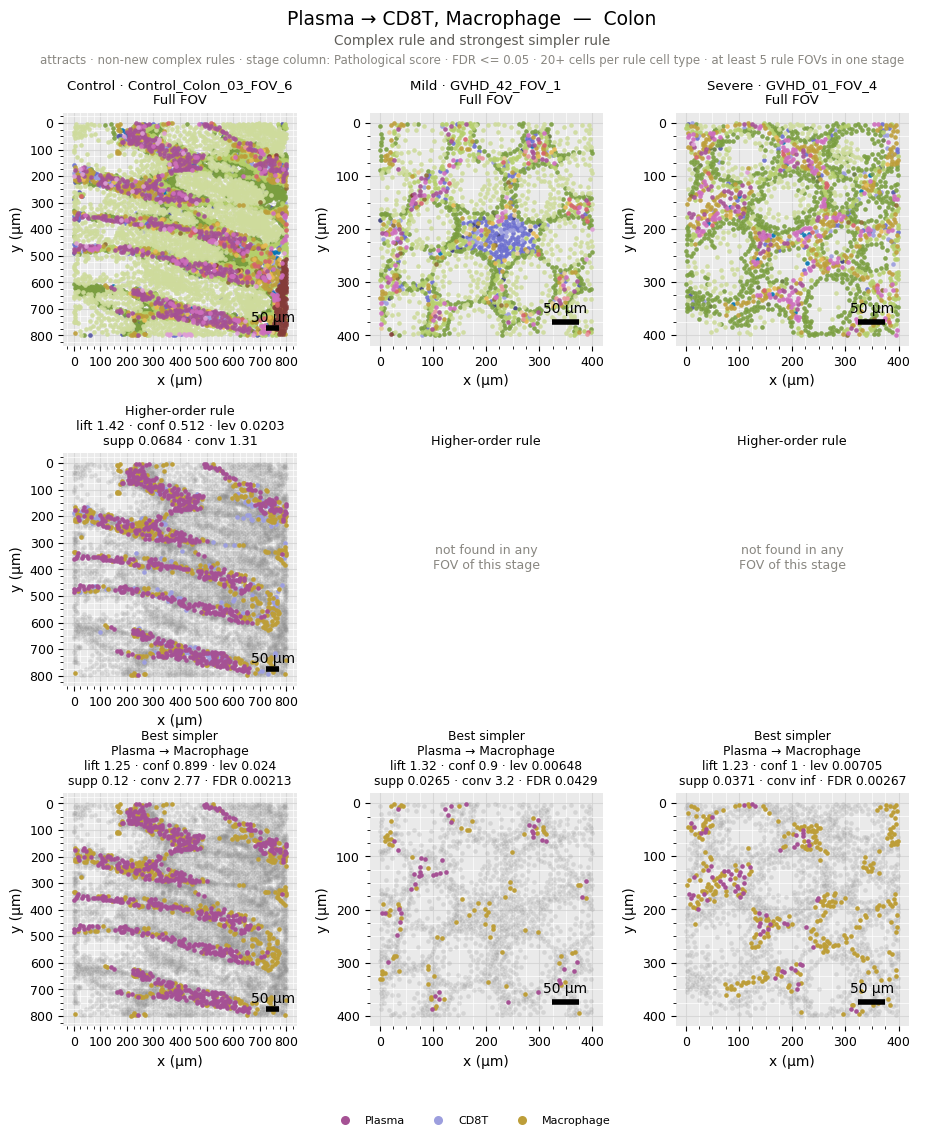

### Duodenum

,name,stage,complex prevalence,simpler prevalence
117,"Epithelial, SMV -> Endothelial",Control,4 / 17 (24%),4 / 17 (24%)
118,"Epithelial, SMV -> Endothelial",Mild,7 / 61 (11%),30 / 61 (49%)
119,"Epithelial, SMV -> Endothelial",Severe,0 / 17 (0%),7 / 17 (41%)
612,"Plasma -> Epithelial, Plasma_CD38",Control,1 / 27 (4%),7 / 27 (26%)
613,"Plasma -> Epithelial, Plasma_CD38",Mild,15 / 67 (22%),17 / 67 (25%)
614,"Plasma -> Epithelial, Plasma_CD38",Severe,0 / 14 (0%),4 / 14 (29%)
186,"Endothelial, Epithelial -> SMV",Control,6 / 17 (35%),1 / 17 (6%)
187,"Endothelial, Epithelial -> SMV",Mild,8 / 61 (13%),21 / 61 (34%)
188,"Endothelial, Epithelial -> SMV",Severe,3 / 17 (18%),3 / 17 (18%)
1101,"Epithelial, SMV -> Plasma",Control,0 / 29 (0%),4 / 29 (14%)


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\elig_path_attracts_duodenum_overview.png


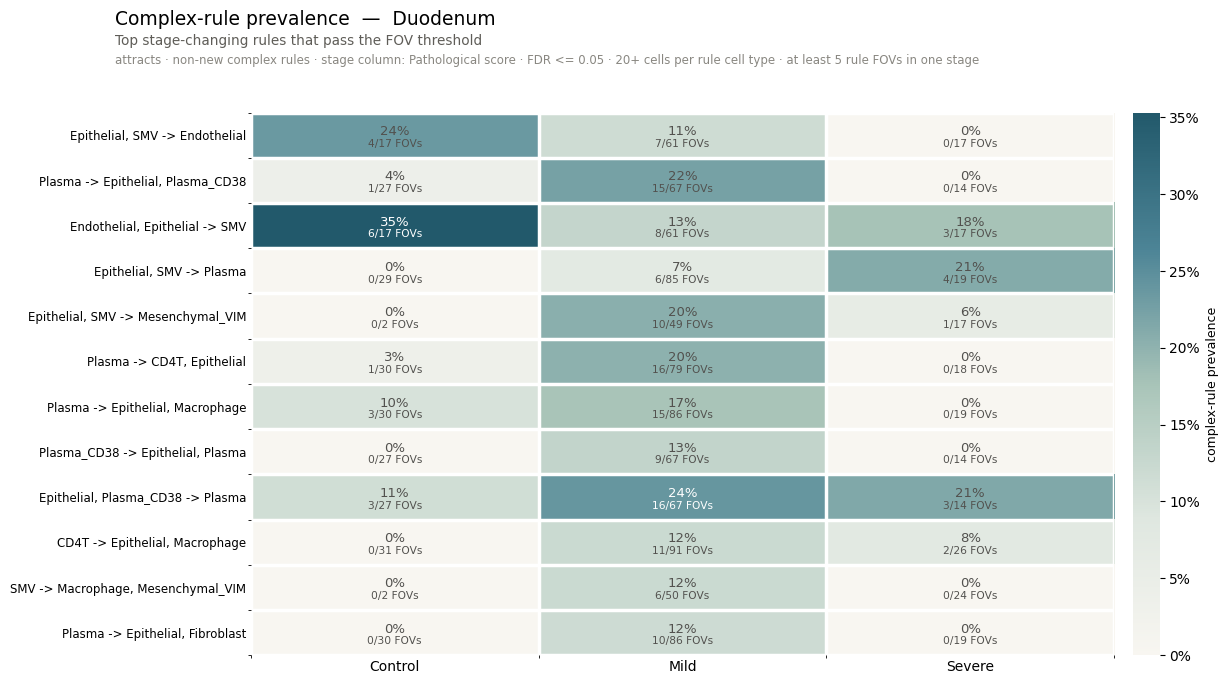

,rule,complex,simpler,FOVs
0,"Epithelial, SMV -> Endothelial",24% -> 0%,24% -> 41%,7
1,"Epithelial, Plasma_CD38 -> Plasma",11% -> 21%,52% -> 29%,16
2,"Endothelial, Epithelial -> SMV",35% -> 18%,6% -> 18%,8


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\elig_path_attracts_duodenum_opposite.png


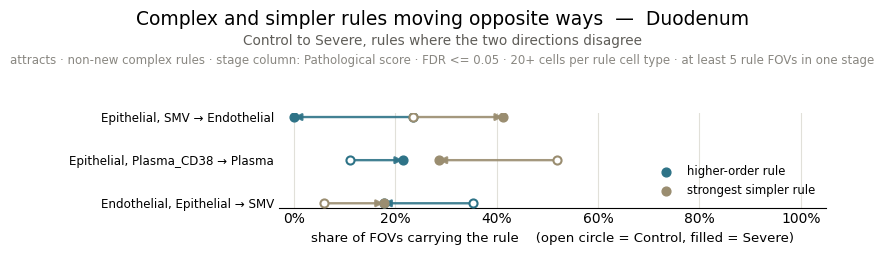

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\elig_path_attracts_duodenum_avail_epithelial_smv_endothelial.png


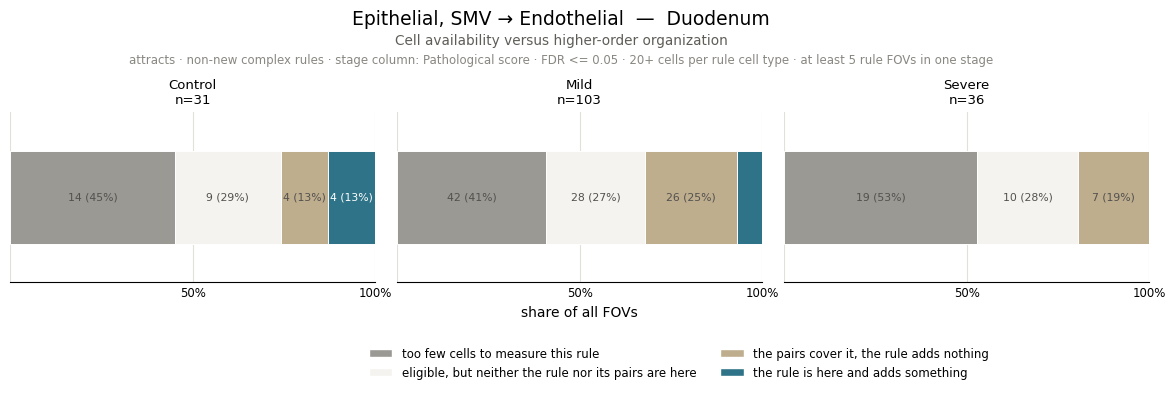

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\elig_path_attracts_duodenum_rule_epithelial_smv_endothelial.png


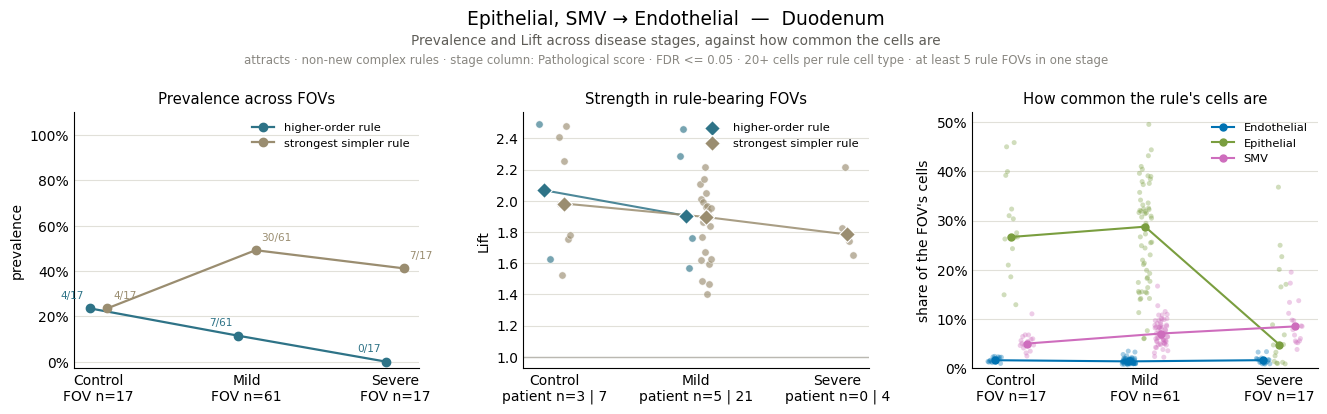

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\elig_path_attracts_duodenum_fovs_epithelial_smv_endothelial.png


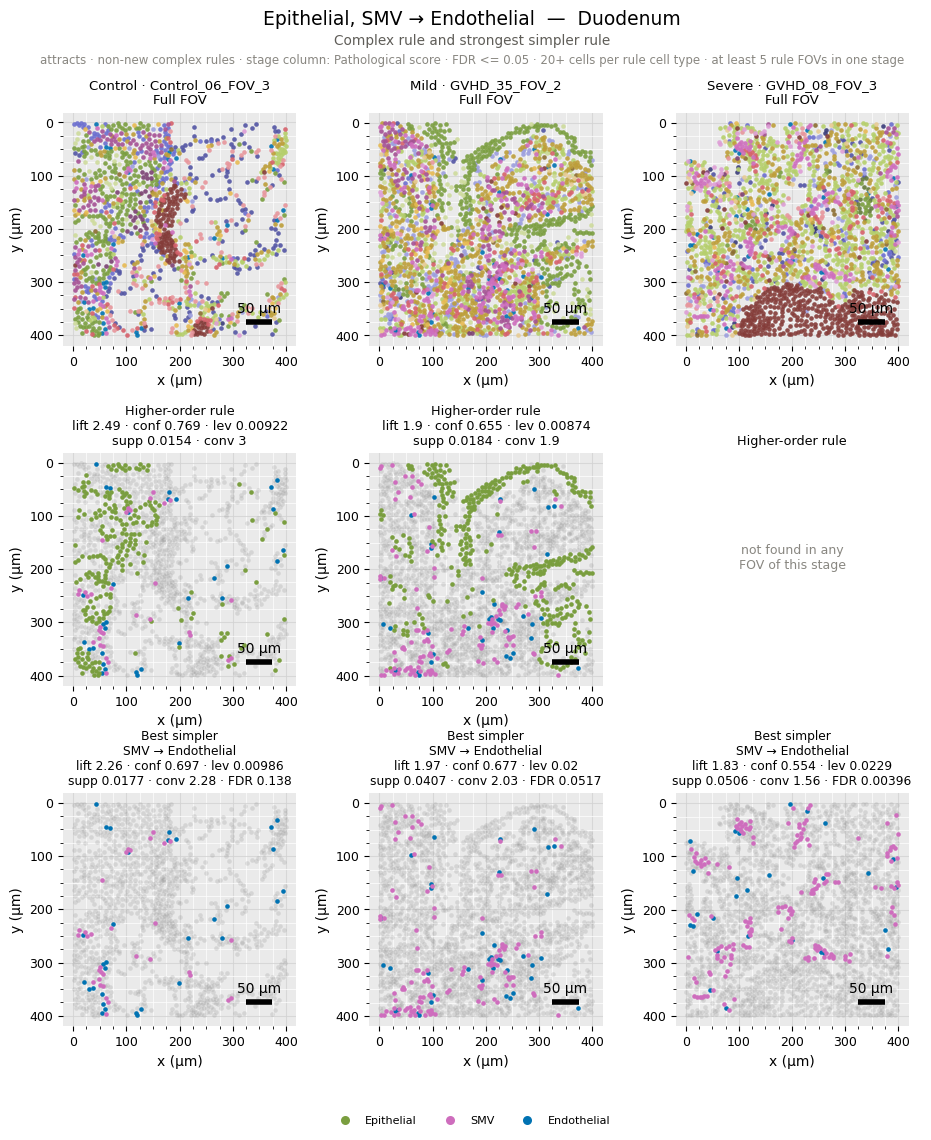

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\elig_path_attracts_duodenum_avail_plasma_epithelial_plasma_cd38.png


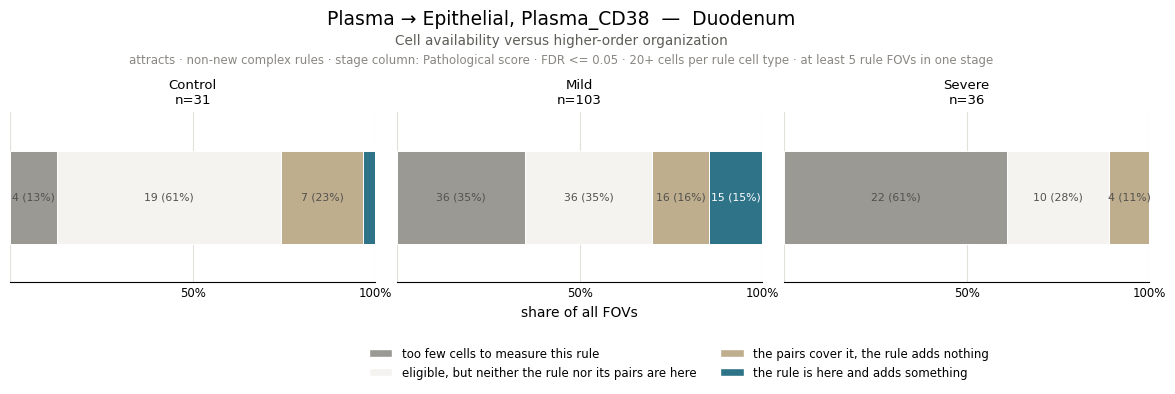

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\elig_path_attracts_duodenum_rule_plasma_epithelial_plasma_cd38.png


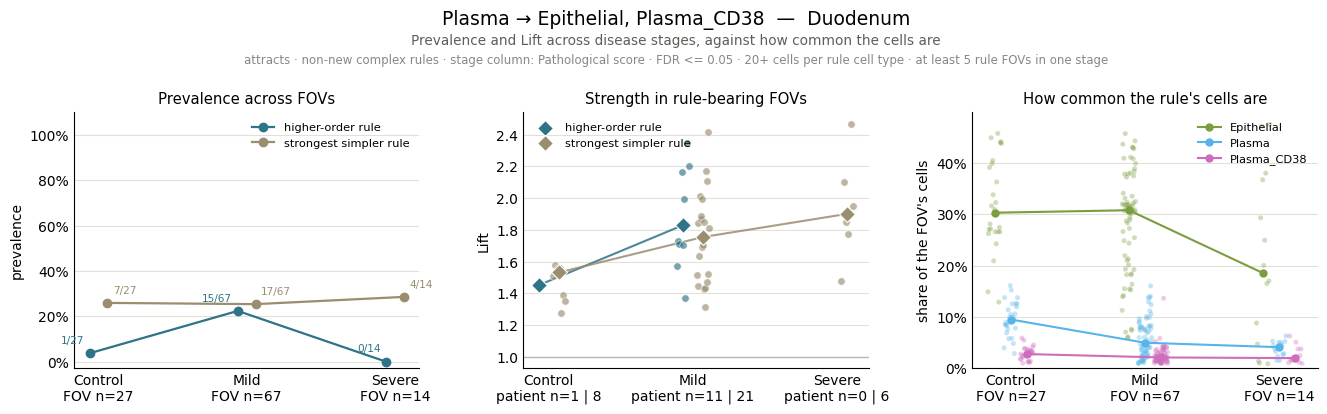

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\elig_path_attracts_duodenum_fovs_plasma_epithelial_plasma_cd38.png


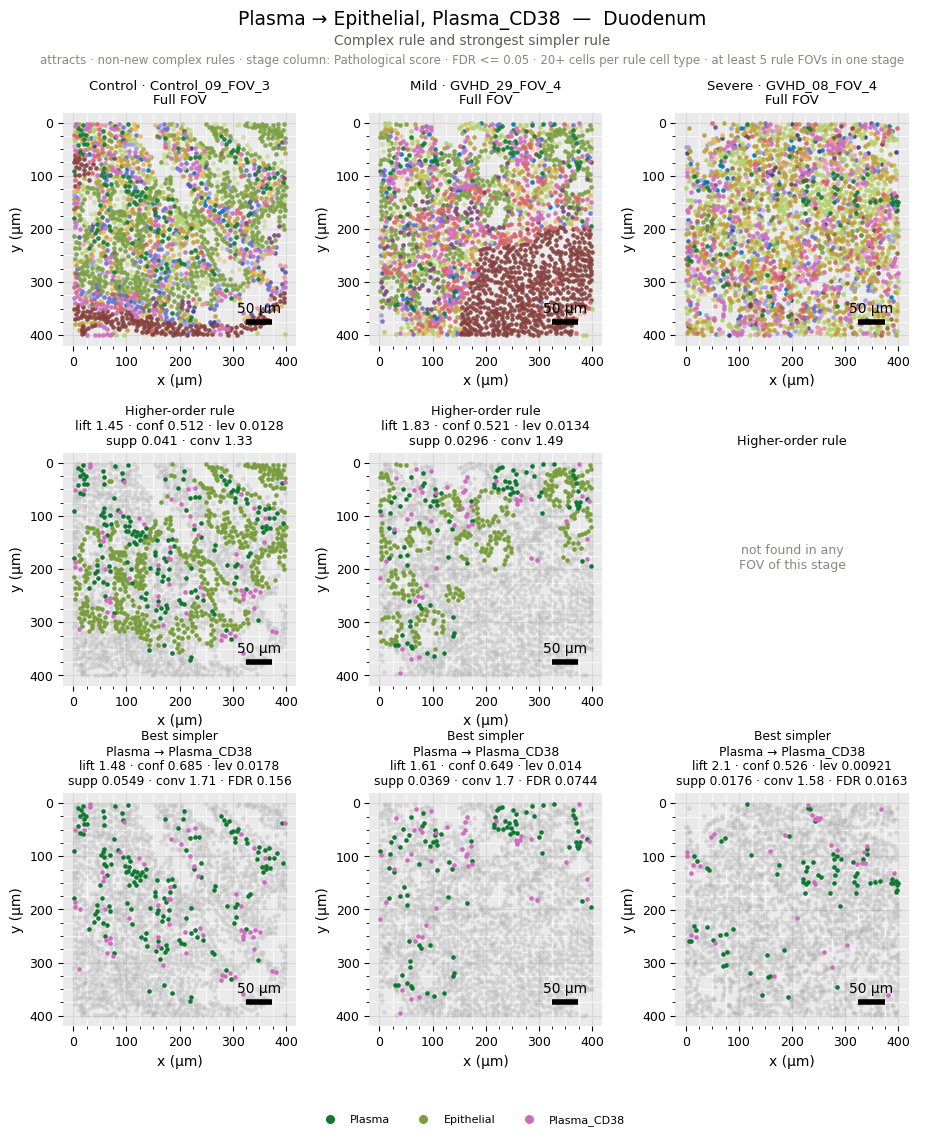

In [6]:
show_kind("attracts")


## Avoidances (negative spatial rules)


## Avoids

### Colon

,name,stage,complex prevalence,simpler prevalence
336,"Goblet -> CD4T, Mast",Control,14 / 14 (100%),14 / 14 (100%)
337,"Goblet -> CD4T, Mast",Mild,2 / 6 (33%),6 / 6 (100%)
338,"Goblet -> CD4T, Mast",Severe,0 / 3 (0%),1 / 3 (33%)
333,"Goblet -> Macrophage, Mast",Control,14 / 14 (100%),14 / 14 (100%)
334,"Goblet -> Macrophage, Mast",Mild,4 / 6 (67%),6 / 6 (100%)
335,"Goblet -> Macrophage, Mast",Severe,0 / 3 (0%),1 / 3 (33%)
150,"Goblet -> CD4T, Plasma_CD38",Control,6 / 9 (67%),9 / 9 (100%)
151,"Goblet -> CD4T, Plasma_CD38",Mild,2 / 2 (100%),2 / 2 (100%)
152,"Goblet -> CD4T, Plasma_CD38",Severe,0 / 4 (0%),3 / 4 (75%)
1413,"Goblet -> CD8T, Mast",Control,13 / 14 (93%),14 / 14 (100%)


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\elig_path_avoids_colon_overview.png


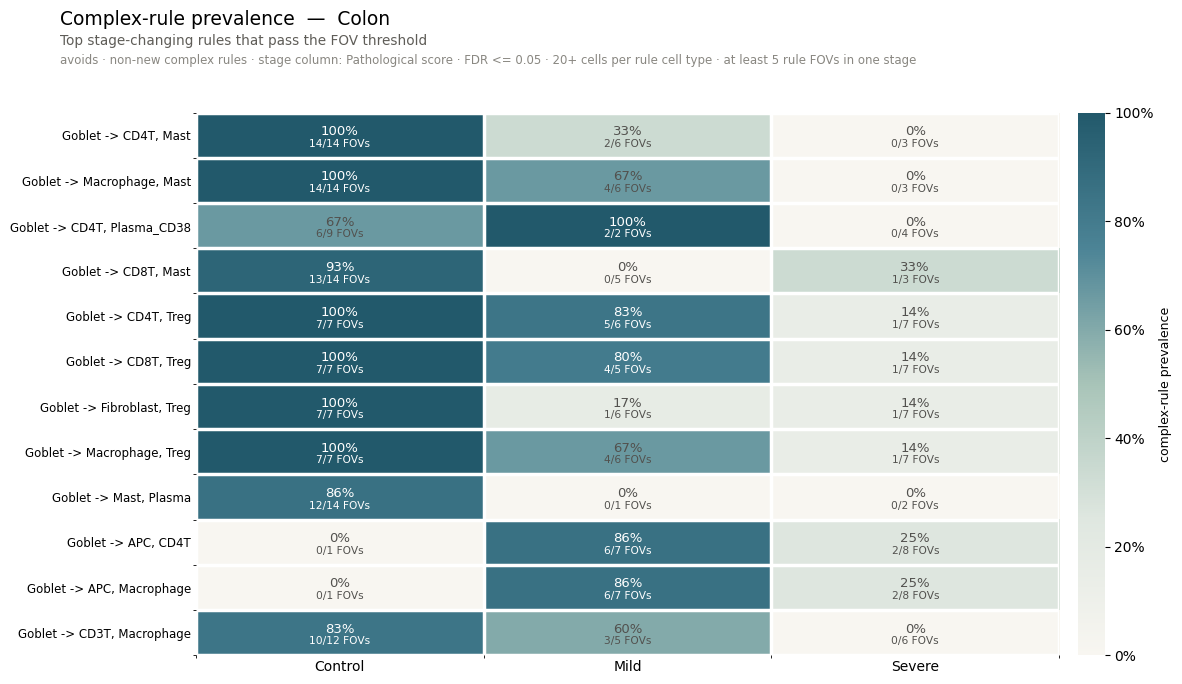

,rule,complex,simpler,FOVs
0,"Goblet -> APC, CD4T",0% -> 25%,100% -> 38%,6
1,"Goblet -> Neutrophil, SMV",0% -> 56%,100% -> 78%,5
2,"Goblet -> CD8T, Neutrophil",0% -> 56%,100% -> 89%,5
3,"Goblet -> APC, Macrophage",0% -> 25%,100% -> 75%,6
4,"Muscle -> Endothelial, Fibroblast",43% -> 12%,71% -> 88%,6
5,"Goblet -> Macrophage, Neutrophil",33% -> 67%,100% -> 89%,6


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\elig_path_avoids_colon_opposite.png


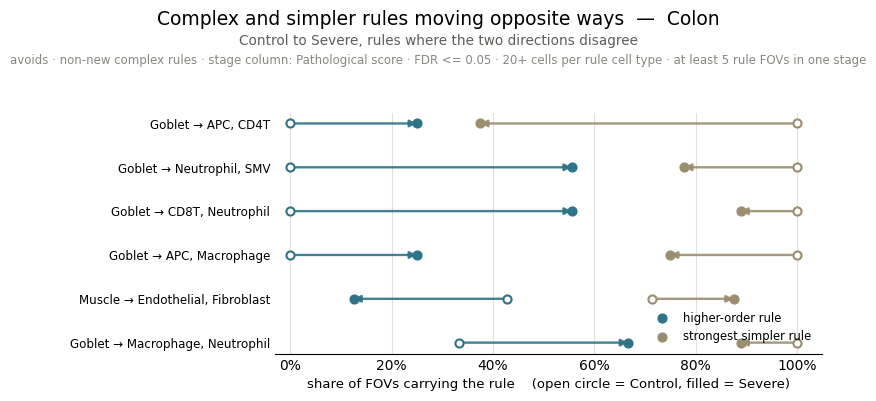

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\elig_path_avoids_colon_avail_goblet_cd4t_mast.png


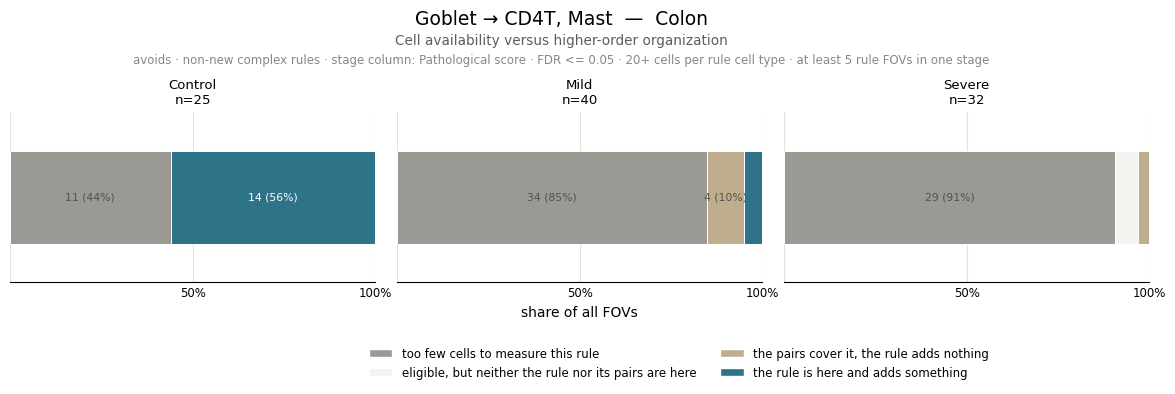

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\elig_path_avoids_colon_rule_goblet_cd4t_mast.png


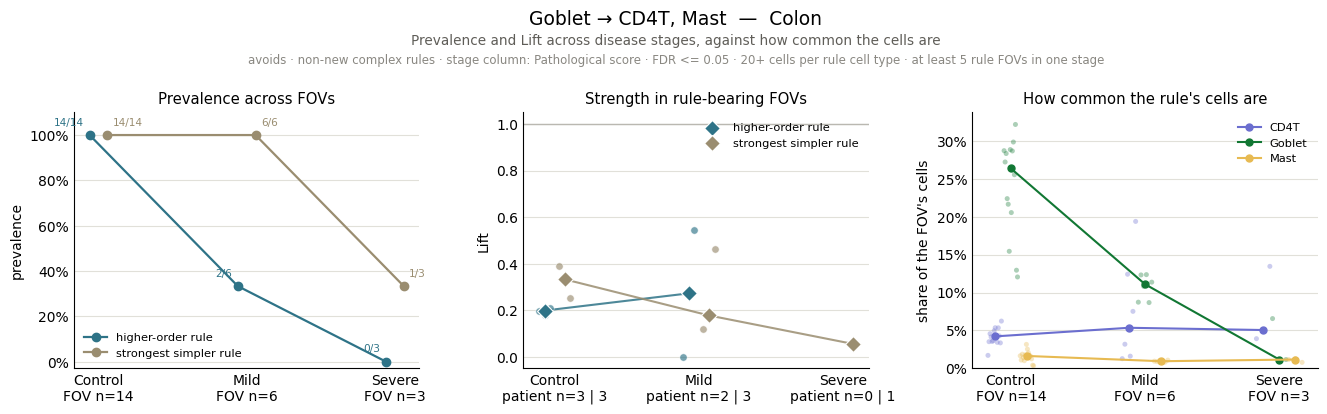

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\elig_path_avoids_colon_fovs_goblet_cd4t_mast.png


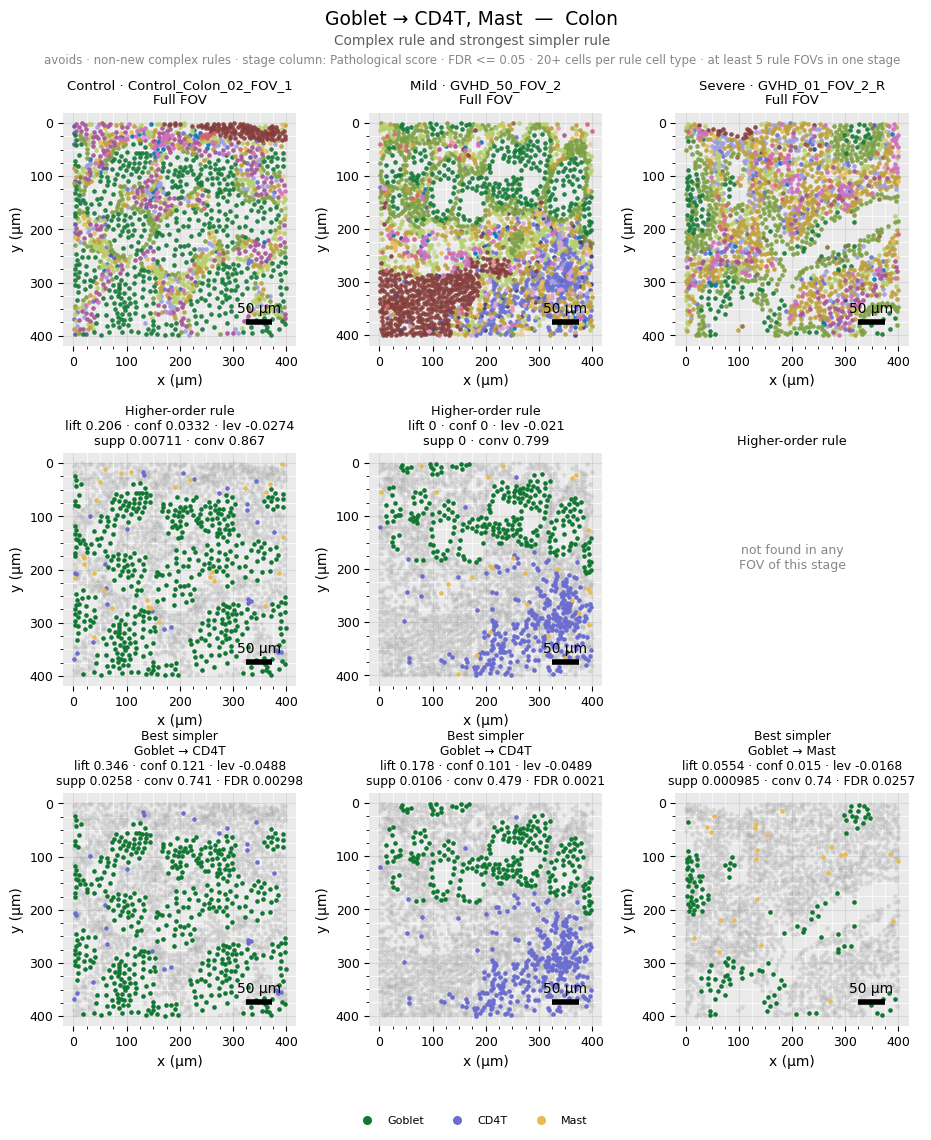

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\elig_path_avoids_colon_avail_goblet_macrophage_mast.png


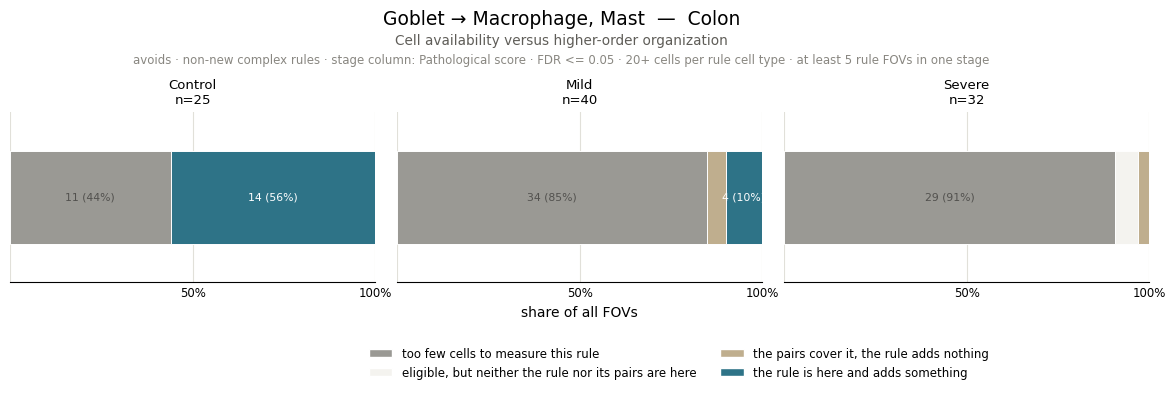

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\elig_path_avoids_colon_rule_goblet_macrophage_mast.png


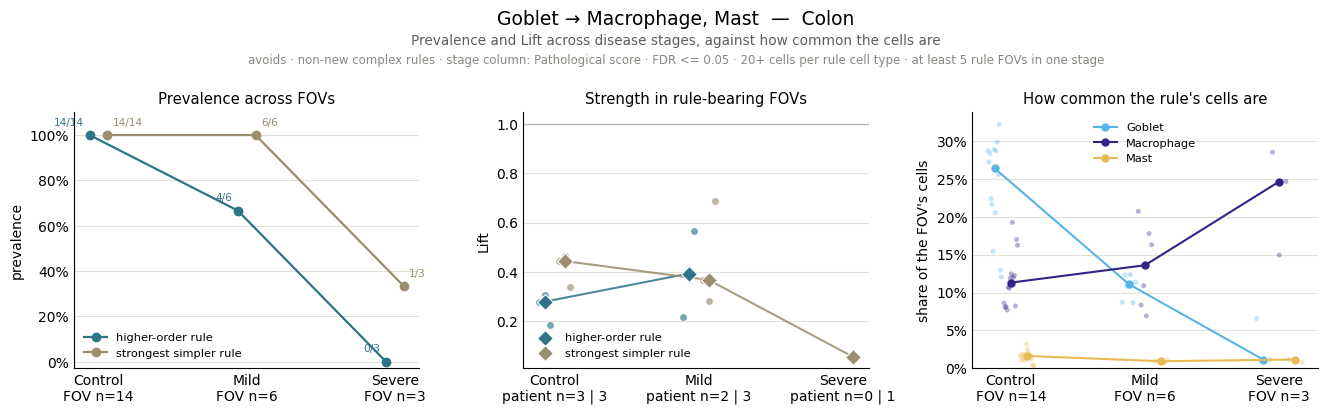

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\elig_path_avoids_colon_fovs_goblet_macrophage_mast.png


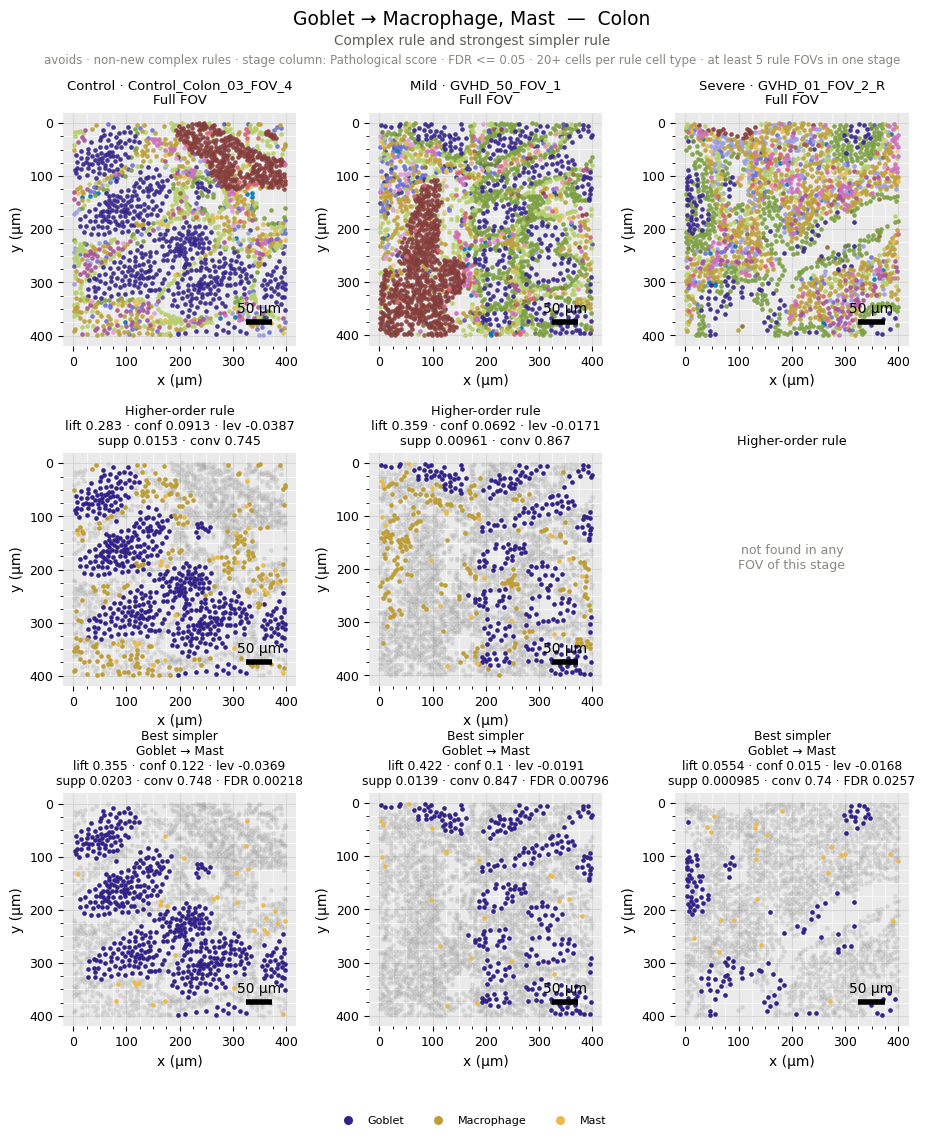

### Duodenum

,name,stage,complex prevalence,simpler prevalence
3810,"BrunnerGland -> Plasma, SMV",Control,0 / 6 (0%),3 / 6 (50%)
3811,"BrunnerGland -> Plasma, SMV",Mild,5 / 15 (33%),9 / 15 (60%)
3812,"BrunnerGland -> Plasma, SMV",Severe,1 / 1 (100%),1 / 1 (100%)
228,"Goblet -> CD8T, Macrophage",Control,9 / 28 (32%),25 / 28 (89%)
229,"Goblet -> CD8T, Macrophage",Mild,26 / 50 (52%),48 / 50 (96%)
230,"Goblet -> CD8T, Macrophage",Severe,7 / 8 (88%),8 / 8 (100%)
603,"Muscle -> Plasma, SMV",Control,1 / 17 (6%),14 / 17 (82%)
604,"Muscle -> Plasma, SMV",Mild,19 / 58 (33%),48 / 58 (83%)
605,"Muscle -> Plasma, SMV",Severe,9 / 15 (60%),13 / 15 (87%)
96,"Epithelial, Goblet -> Muscle",Control,2 / 17 (12%),2 / 17 (12%)


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\elig_path_avoids_duodenum_overview.png


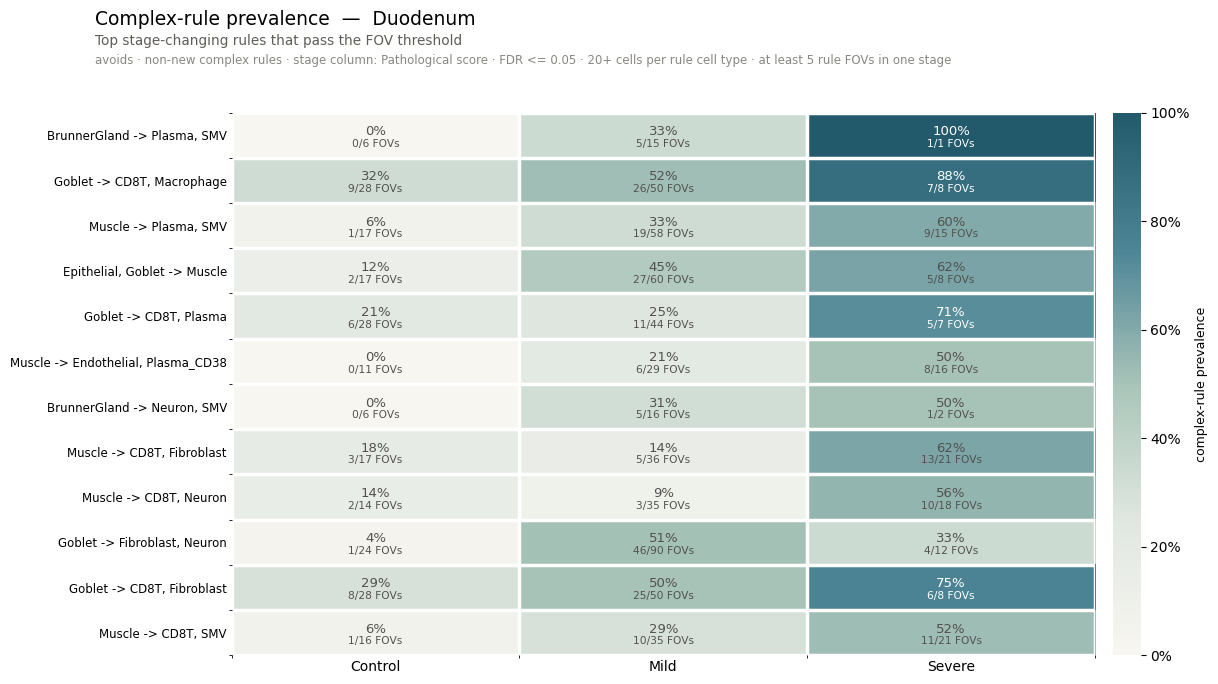

,rule,complex,simpler,FOVs
0,"BrunnerGland -> Macrophage, Neuron",17% -> 0%,33% -> 100%,5
1,"BrunnerGland -> Macrophage, Plasma",17% -> 0%,50% -> 100%,5
2,"Fibroblast, Mesenchymal_VIM -> Goblet",0% -> 25%,100% -> 75%,19
3,"Goblet -> Fibroblast, ImmuneOther",11% -> 43%,100% -> 86%,11
4,"Macrophage, Muscle -> Plasma_CD38",12% -> 0%,53% -> 86%,6
5,"Endothelial, Fibroblast -> Goblet",11% -> 0%,44% -> 67%,14
6,"Goblet -> Neuron, Plasma",12% -> 30%,75% -> 60%,19


saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\elig_path_avoids_duodenum_opposite.png


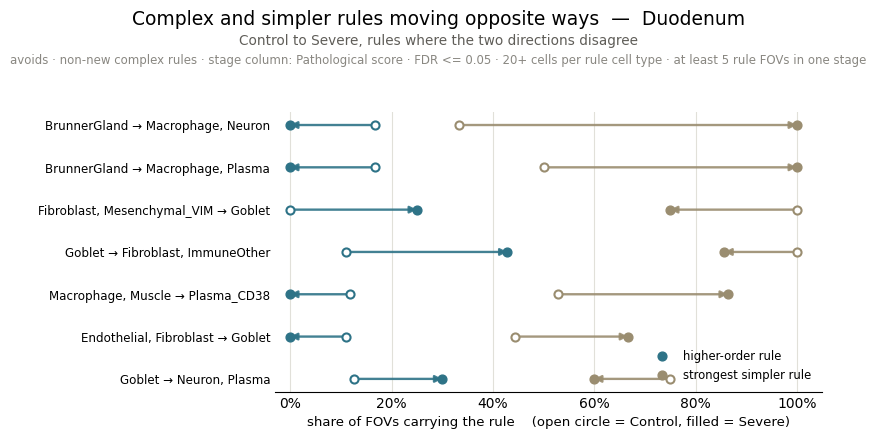

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\elig_path_avoids_duodenum_avail_brunnergland_plasma_smv.png


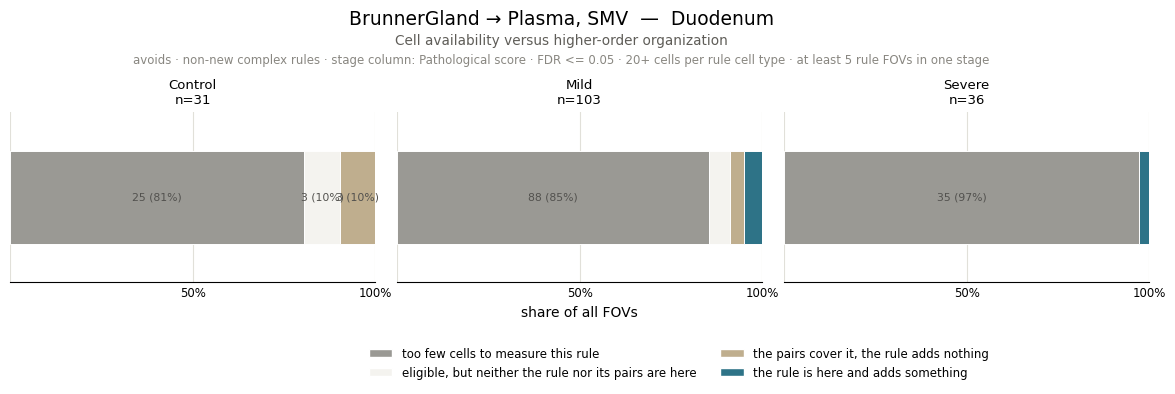

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\elig_path_avoids_duodenum_rule_brunnergland_plasma_smv.png


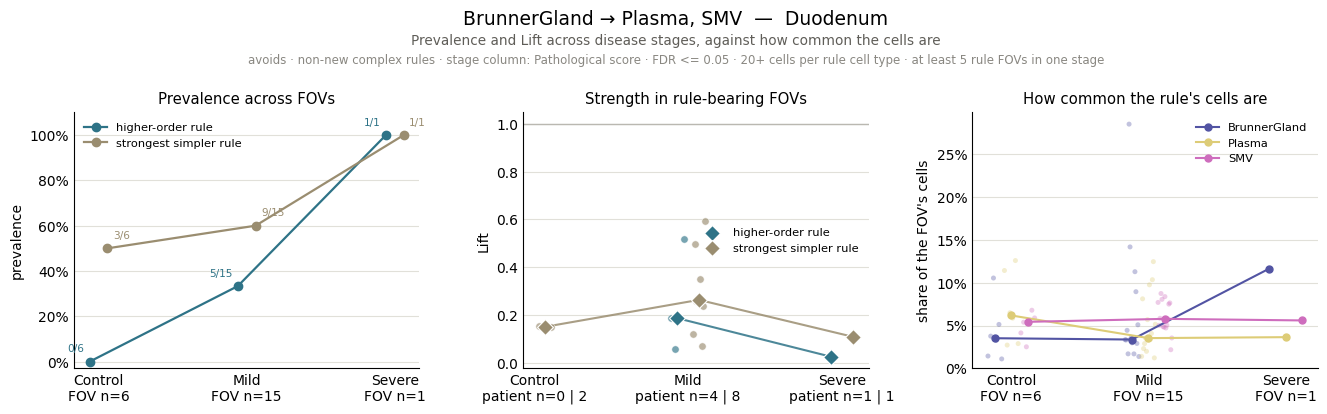

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\elig_path_avoids_duodenum_fovs_brunnergland_plasma_smv.png


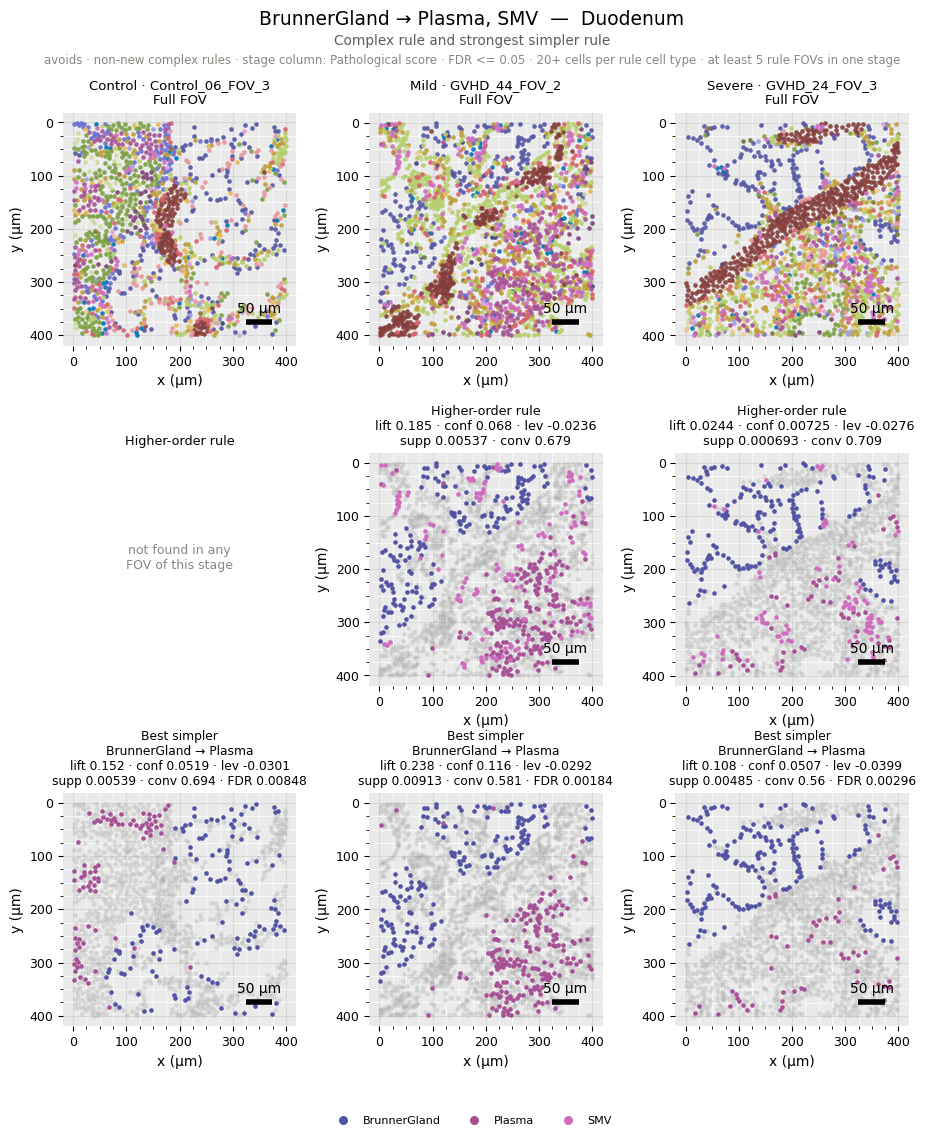

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\elig_path_avoids_duodenum_avail_goblet_cd8t_macrophage.png


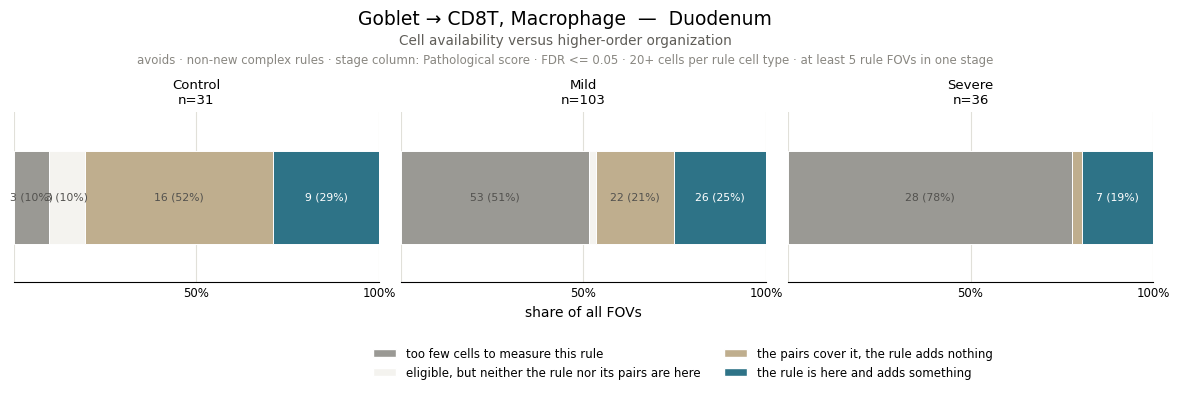

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\elig_path_avoids_duodenum_rule_goblet_cd8t_macrophage.png


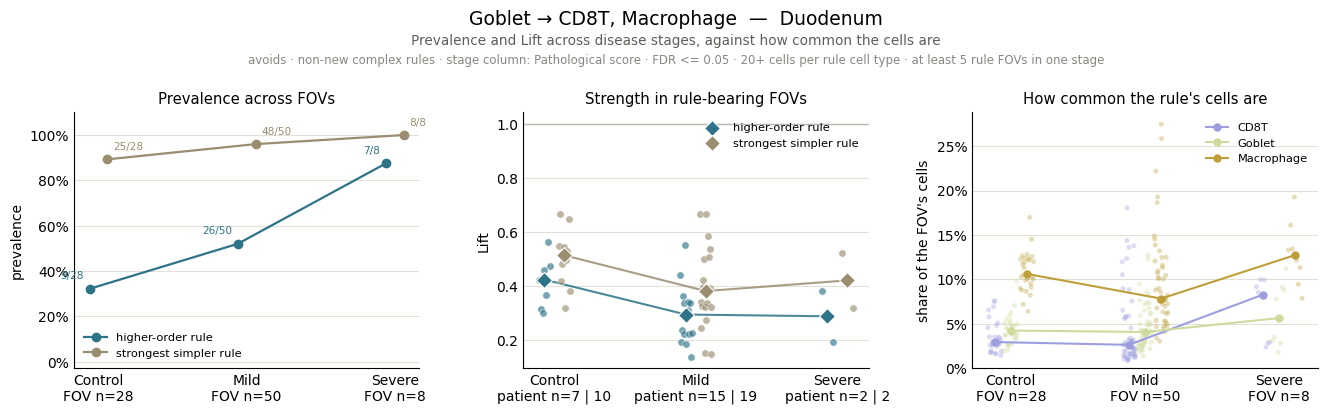

saved C:\Users\Owner\Documents\script-rule-mining\result_summary\complex_rules\summary_downloads\elig_path_avoids_duodenum_fovs_goblet_cd8t_macrophage.png


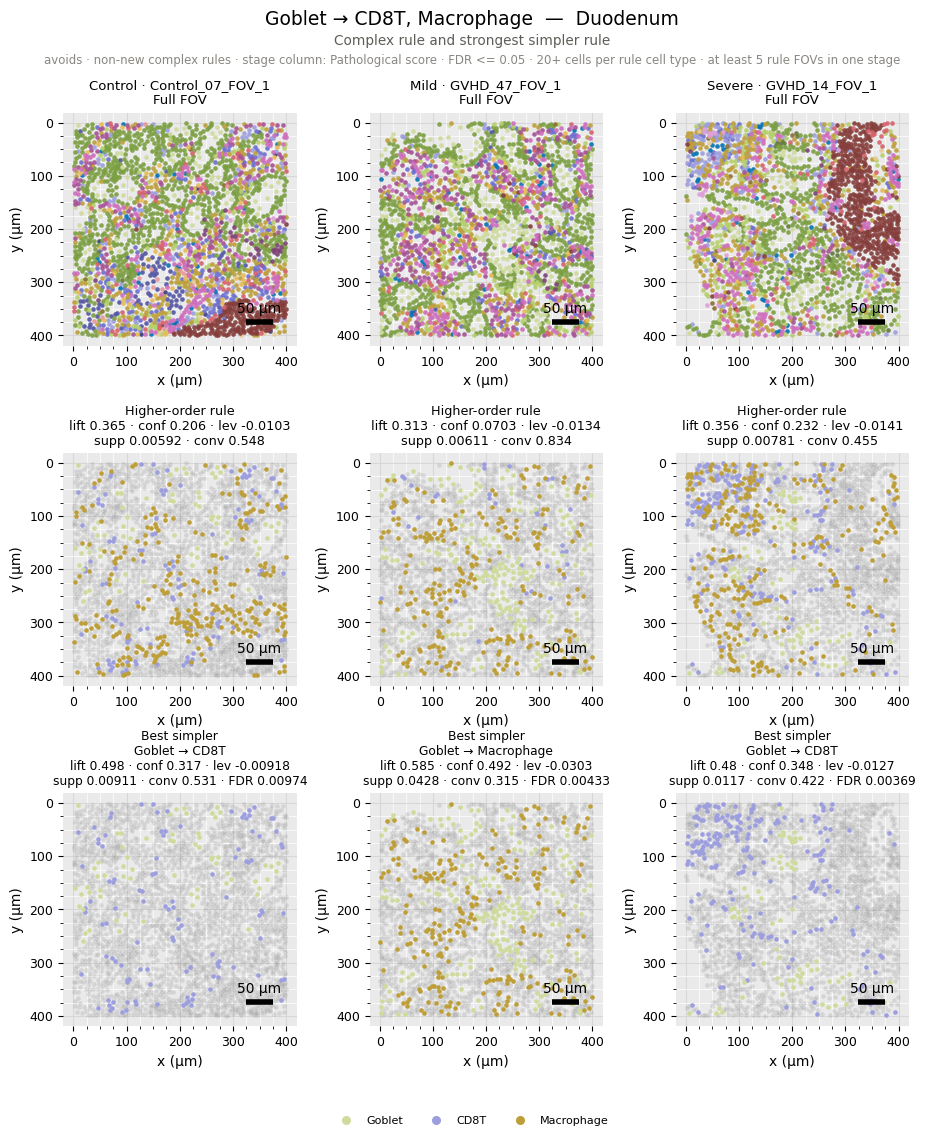

In [7]:
show_kind("avoids")
